## Analisis de Datos Exploratorio univariable (EDA)

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-20

### Description:

Realizar un buen análisis de datos exploratorio (EDA) para caracterizar los datos disponibles para el proyecto.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd

In [2]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [4]:
DATA_DIR = Path.cwd().resolve().parents[0] / "Admisiones-predict-project" / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

## 📊 Data description

In [5]:
admisiones_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          612 non-null    Int64  
 1   TOEFL Score        604 non-null    Int64  
 2   University Rating  617 non-null    Int64  
 3   SOP                607 non-null    float64
 4   LOR                615 non-null    float64
 5   CGPA               621 non-null    float64
 6   Research           594 non-null    boolean
 7   Chance of Admit    623 non-null    float64
dtypes: Int64(3), boolean(1), float64(4)
memory usage: 37.2 KB


In [6]:
admisiones_df.shape

(623, 8)

In [7]:
# sample of the dataframe
admisiones_df.sample(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
357,301,104,2,3.50,3.50,7.89,True,0.68
89,316,109,4,4.50,3.50,8.76,True,0.74
282,312,106,3,4.00,3.50,8.79,True,0.81
183,314,110,3,4.00,4.00,8.80,False,0.75
550,312,104,3,3.50,3.50,8.42,False,0.74
539,305,106,2,3.00,3.00,8.16,False,0.64
395,324,110,3,3.50,3.50,9.04,True,0.82
120,335,117,5,5.00,5.00,9.56,True,0.94
255,307,110,4,4.00,4.50,8.37,False,0.79
317,300,99,1,1.00,2.50,8.01,False,0.58


In [8]:
admisiones_df.isnull().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

In [9]:
admisiones_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit
count,612.00,604.00,617.00,607.00,615.00,621.00,623.00
mean,317.09,107.87,3.18,3.46,3.52,8.64,0.73
std,11.75,6.12,1.15,1.01,0.87,0.59,0.14
min,290.00,92.00,1.00,1.00,1.00,6.80,0.34
25%,309.00,104.00,2.00,3.00,3.00,8.22,0.64
50%,317.00,108.00,3.00,3.50,3.50,8.65,0.73
75%,326.00,112.00,4.00,4.00,4.00,9.10,0.84
max,340.00,120.00,5.00,5.00,5.00,9.92,0.97


## Target variable

In [11]:
admisiones_df["Chance of Admit "].describe()

count   623.00
mean      0.73
std       0.14
min       0.34
25%       0.64
50%       0.73
75%       0.84
max       0.97
Name: Chance of Admit , dtype: float64

In [12]:
admisiones_df["Chance of Admit "].nunique()

60

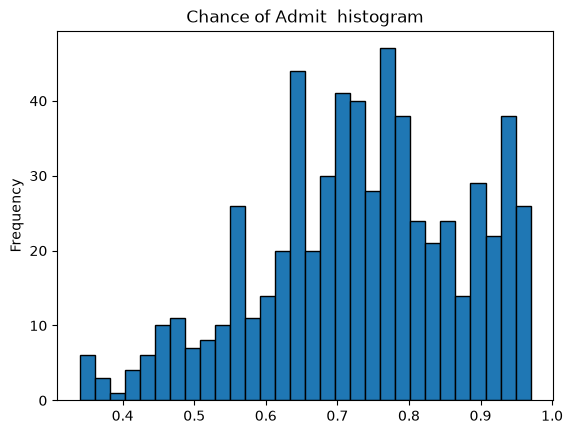

In [15]:
admisiones_df["Chance of Admit "].plot(
    kind="hist", bins=30, edgecolor="black", title="Chance of Admit  histogram"
);

<Axes: title={'center': 'Chance of Admit  distribution'}, ylabel='Density'>

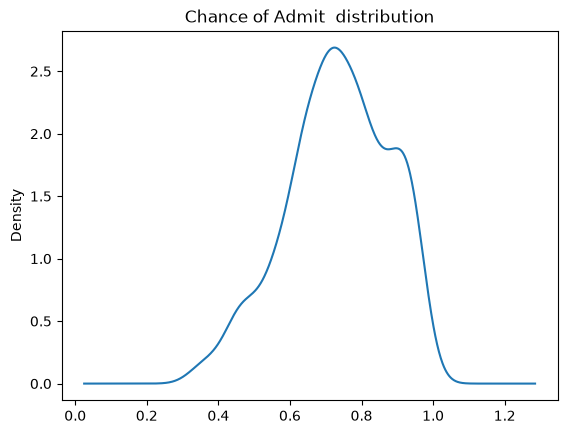

In [ ]:
admisiones_df["Chance of Admit "].plot(kind="density", title="Chance of Admit  distribution")

<Axes: title={'center': 'Chance of Admit  boxplot'}>

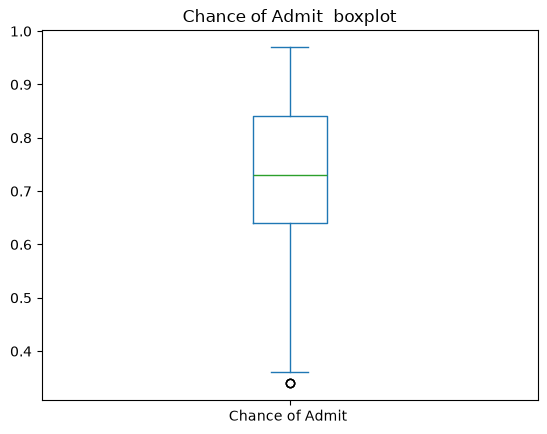

In [18]:
admisiones_df["Chance of Admit "].plot(kind="box", title="Chance of Admit  boxplot")

## bool variables

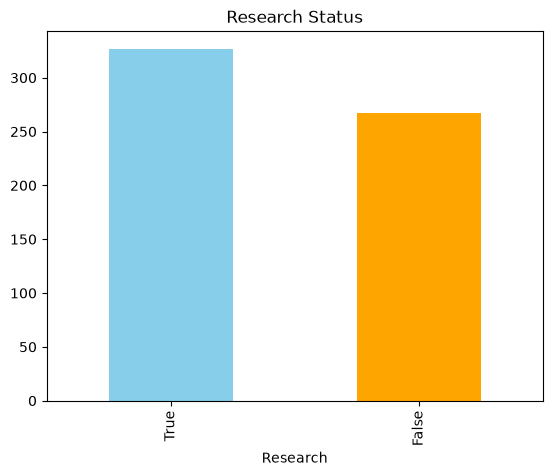

In [10]:
admisiones_df["Research"].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title="Research Status"
);

## Numerical Variables

In [19]:
# list of the numerical columns
numerical_columns = list(admisiones_df.select_dtypes(include=["number"]).columns)
numerical_columns.remove("Chance of Admit ")  # remove the target variable from the list
numerical_columns

['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA']


Variable: GRE Score


,value
count,612.00
mean,317.09
std,11.75
min,290.00
25%,309.00
50%,317.00
75%,326.00
max,340.00


Valores únicos: 49
Valores nulos: 11


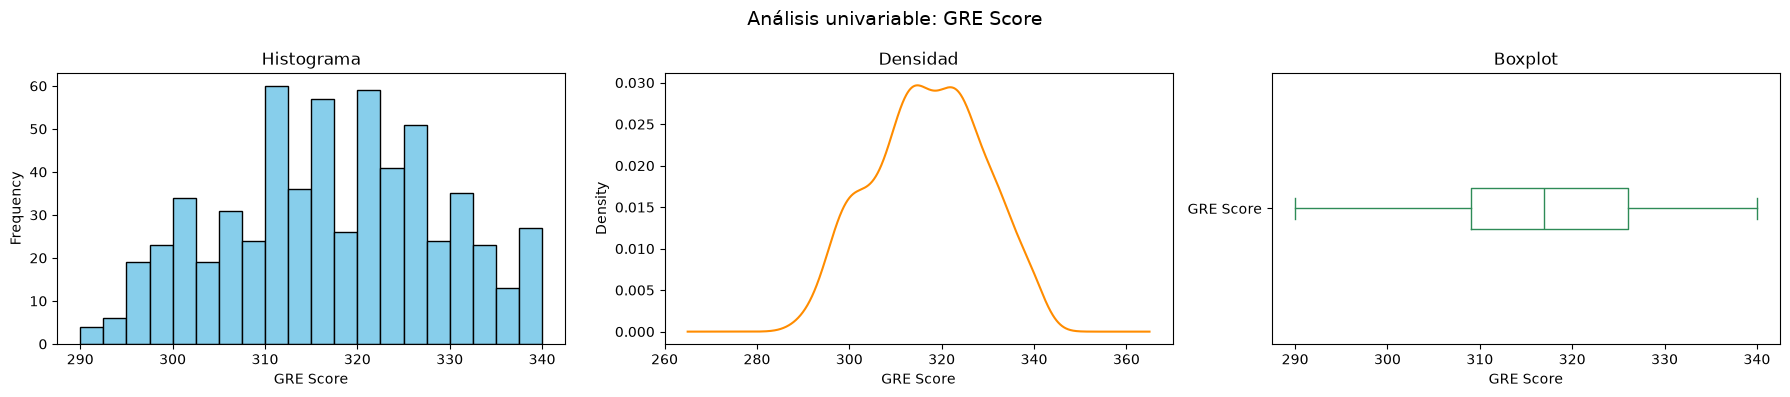


Variable: TOEFL Score


,value
count,604.00
mean,107.87
std,6.12
min,92.00
25%,104.00
50%,108.00
75%,112.00
max,120.00


Valores únicos: 29
Valores nulos: 19


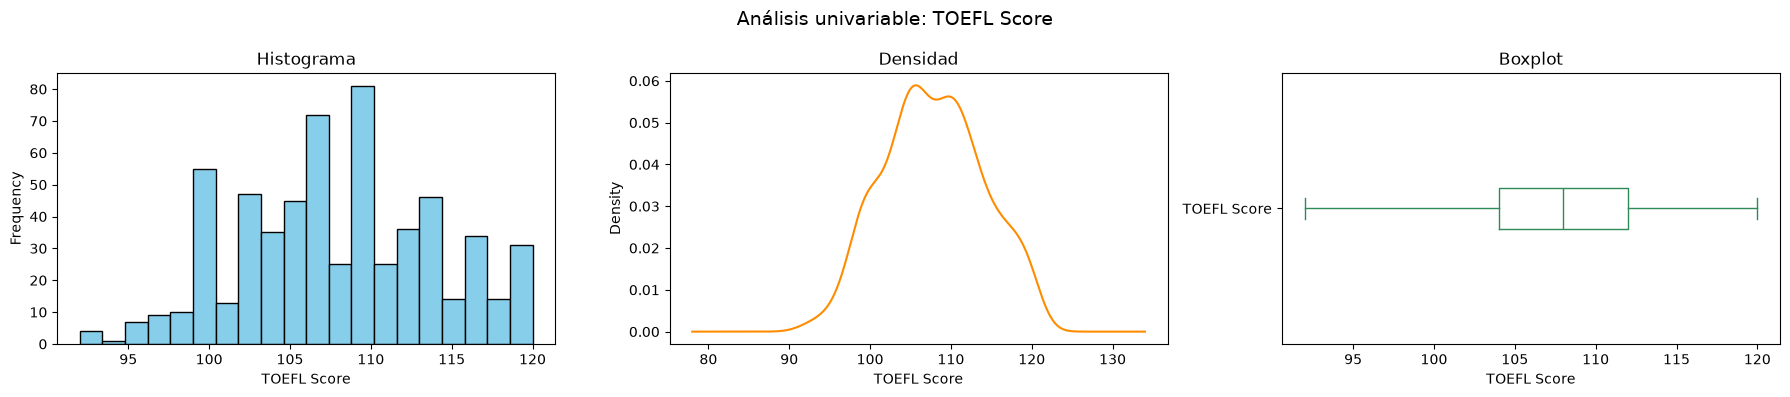


Variable: University Rating


,value
count,617.00
mean,3.18
std,1.15
min,1.00
25%,2.00
50%,3.00
75%,4.00
max,5.00


Valores únicos: 5
Valores nulos: 6


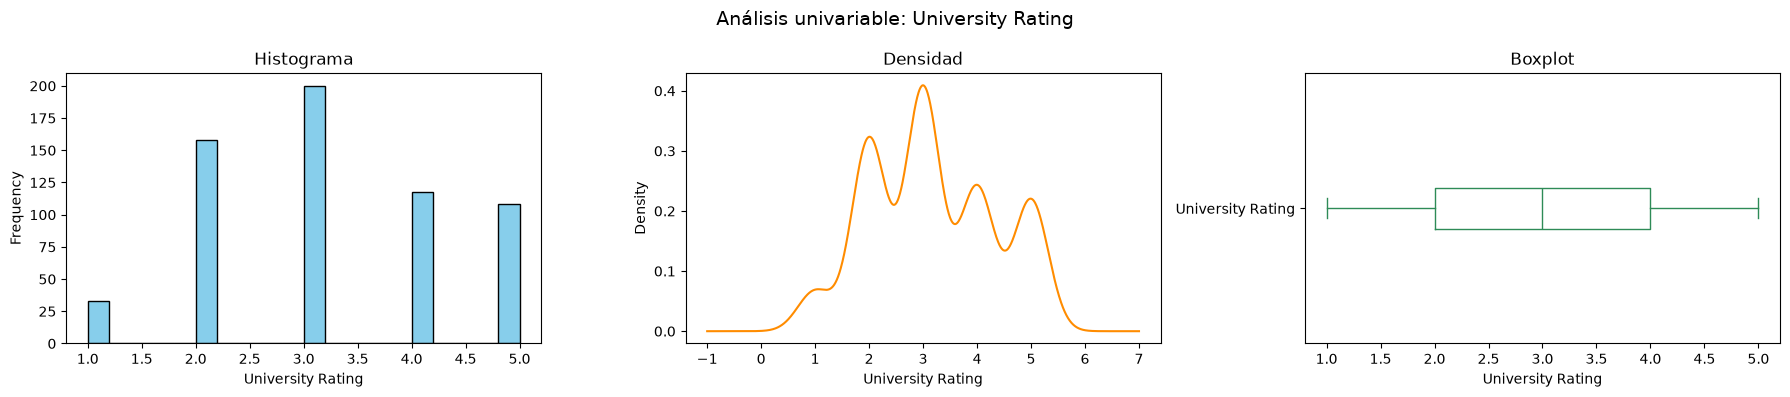


Variable: SOP


,value
count,607.00
mean,3.46
std,1.01
min,1.00
25%,3.00
50%,3.50
75%,4.00
max,5.00


Valores únicos: 9
Valores nulos: 16


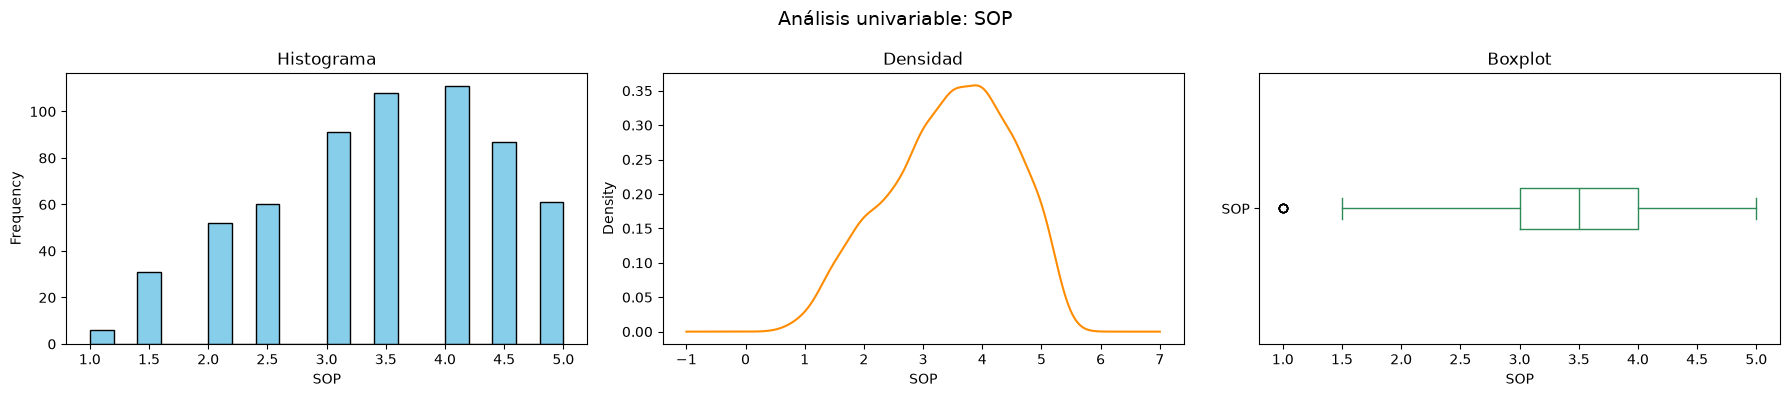


Variable: LOR 


,value
count,615.00
mean,3.52
std,0.87
min,1.00
25%,3.00
50%,3.50
75%,4.00
max,5.00


Valores únicos: 9
Valores nulos: 8


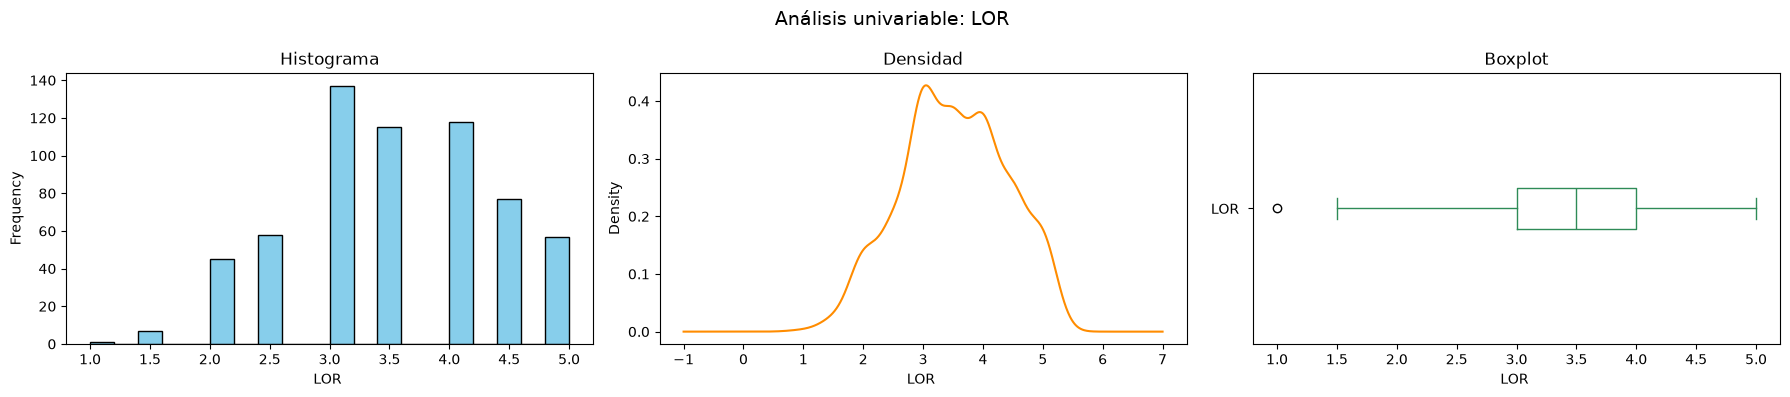


Variable: CGPA


,value
count,621.00
mean,8.64
std,0.59
min,6.80
25%,8.22
50%,8.65
75%,9.10
max,9.92


Valores únicos: 168
Valores nulos: 2


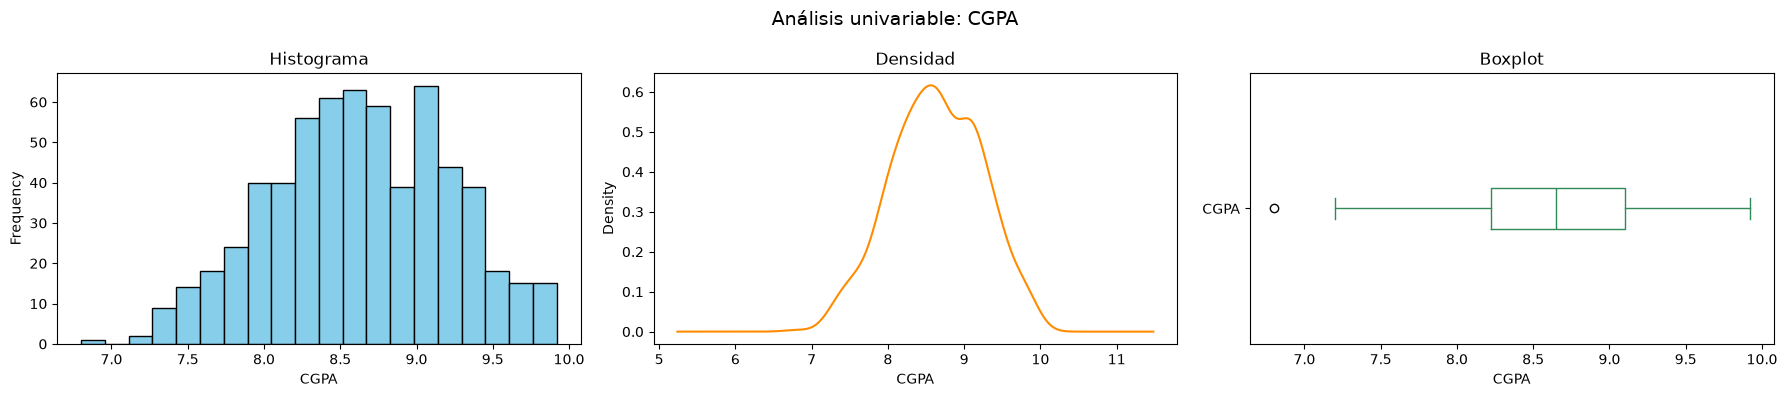

In [20]:
import matplotlib.pyplot as plt
from IPython.display import display

for col in numerical_columns:
    serie = admisiones_df[col].dropna()

    print(f"\n{'=' * 60}\nVariable: {col}")
    display(serie.describe().to_frame(name="value"))
    print(f"Valores únicos: {serie.nunique()}")
    print(f"Valores nulos: {admisiones_df[col].isna().sum()}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Análisis univariable: {col}", fontsize=14)

    serie.plot.hist(ax=axes[0], bins=20, edgecolor="black", color="skyblue")
    axes[0].set_title("Histograma")
    axes[0].set_xlabel(col)

    serie.plot.kde(ax=axes[1], color="darkorange")
    axes[1].set_title("Densidad")
    axes[1].set_xlabel(col)

    serie.plot.box(ax=axes[2], vert=False, color="seagreen")
    axes[2].set_title("Boxplot")
    axes[2].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


### Evidencia del análisis univariable

**Estructura del conjunto de datos.** El conjunto de datos contiene 623 filas y 8 columnas. Chance of Admit es la variable objetivo y está completa (623 valores no nulos). Las variables restantes son predictores candidatos: GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA y Research.

**Datos faltantes.** Todos los predictores candidatos tienen valores faltantes: GRE Score 11 (1.8%), TOEFL Score 19 (3.1%), University Rating 6 (1.0%), SOP 16 (2.6%), LOR 8 (1.3%), CGPA 2 (0.3%) y Research 29 (4.7%). La variable objetivo no tiene valores faltantes. Por lo tanto, eliminar filas con algún predictor faltante reduciría la muestra disponible para entrenamiento y no debería ser la opción predeterminada sin evaluar el patrón de ausencia.

**Tipos de variables y rangos observados.** GRE Score, TOEFL Score y CGPA son mediciones numéricas (rangos observados: 290-340, 92-120 y 6.80-9.92, respectivamente). University Rating, SOP y LOR son escalas ordinales acotadas de 1 a 5 y no deberían tratarse como cantidades continuas sin restricciones; SOP y LOR también aparecen en incrementos de medio punto. Research es una variable booleana anulable, con 327 valores True, 267 False y 29 faltantes.

**Valores centrales relevantes para el modelado.** La variable objetivo tiene una media y mediana de 0.73, un rango intercuartílico de 0.64-0.84 y un rango observado de 0.34-0.97. Las medianas de los predictores son 317 para GRE Score, 108 para TOEFL Score, 3 para University Rating, 3.5 para SOP, 3.5 para LOR y 8.65 para CGPA. Estos resúmenes describen únicamente la muestra observada; no establecen relaciones entre predictores y objetivo ni el rendimiento de un modelo.

**Cautela sobre distribución y valores atípicos.** Los resúmenes y gráficos univariables permiten revisar el rango y la frecuencia de cada variable, pero no demuestran normalidad ni justifican eliminar observaciones. Los valores cercanos a los límites de las escalas acotadas y de los rangos numéricos observados deben validarse con la fuente de datos antes de clasificarse como valores atípicos.

### Recomendaciones para preparación y validación de datos

1. Dividir los datos en conjuntos de entrenamiento y validación antes de ajustar cualquier imputador, escalador o codificador para prevenir fuga de información.
2. Analizar los valores faltantes por variable y, cuando sea posible, frente a otros atributos observados. Comparar una línea base con casos completos frente a imputación por pliegue de entrenamiento e indicadores de ausencia; seleccionar el enfoque con resultados de validación en lugar de asumir un mecanismo de ausencia.
3. Conservar Research como atributo binario y manejar explícitamente su estado faltante. Mantener el orden de University Rating, SOP y LOR; evaluar codificaciones ordinales frente a categóricas mediante validación, en lugar de asumir igual distancia entre calificaciones.
4. Estandarizar GRE Score, TOEFL Score y CGPA solo para modelos sensibles a la escala, ajustando la transformación en los pliegues de entrenamiento. No usar los resúmenes univariables como fundamento para eliminar automáticamente valores atípicos.
5. Evaluar modelos candidatos de regresión con validación cruzada reproducible o un conjunto de validación separado. Reportar métricas de error adecuadas para la variable objetivo y comparar contra una línea base simple antes de concluir sobre su utilidad predictiva.
